— Celda 0 — Instalación de librerías

In [1]:
# Celda 0 — Instalación de dependencias (versiones corregidas)

!pip install yfinance==0.2.38 --quiet
!pip install pandas-ta==0.4.71b0 --quiet
!pip install ta==0.11.0 --quiet
!pip install requests beautifulsoup4 lxml --quiet

# Verificación real (no un print ciego)
import importlib, sys

libs = {
    "yfinance":   "0.2.38",
    "pandas_ta":  "0.4.71b0",
    "ta":         "0.11.0",
}

all_ok = True
for lib, expected_ver in libs.items():
    try:
        mod = importlib.import_module(lib)
        ver = getattr(mod, "__version__", "desconocida")
        print(f"  ✅ {lib} — {ver}")
    except ImportError:
        print(f"  ❌ {lib} — NO INSTALADO")
        all_ok = False

if all_ok:
    print("\n✅ Todas las librerías instaladas correctamente")
else:
    print("\n⚠️  Hay librerías con problemas. Revisa los errores arriba.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.0/73.0 kB 2.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 4.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 240.3/240.3 kB 18.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 99.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.5/16.5 MB 78.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 103.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.4/42.4 MB 16.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.1 which is incompatible.
gradio 5.50.0 requires pandas<3.0,>=1.0, but you have pandas 3.0.1 which is incompatible.
db-dtypes

— Celda 1 — Imports y configuración global

In [2]:
# Celda 1 — Imports y configuración del entorno

import os
import warnings
import logging
from datetime import datetime, timedelta

import numpy as np
import pandas as pd
import yfinance as yf

# Indicadores técnicos
import pandas_ta as pta
from ta import add_all_ta_features
from ta.trend import MACD, EMAIndicator, SMAIndicator
from ta.momentum import RSIIndicator, StochasticOscillator
from ta.volatility import BollingerBands, AverageTrueRange
from ta.volume import OnBalanceVolumeIndicator

# Visualización (opcional pero útil para validar)
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Configuración de logging profesional
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s — %(levelname)s — %(message)s",
    datefmt="%Y-%m-%d %H:%M:%S"
)
logger = logging.getLogger(__name__)

# Suprimir warnings menores de yfinance
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

# ─── CONFIGURACIÓN CENTRAL DEL PROYECTO ─────────────────────────────────────
CONFIG = {
    # Ticker del ETF del IBEX 35 en Yahoo Finance
    # EXS1.DE = iShares IBEX 35 UCITS ETF (más líquido, cotiza en Xetra)
    # ^IBEX   = Índice IBEX 35 puro (útil como referencia)
    "PRIMARY_TICKER":    "EXS1.DE",
    "BENCHMARK_TICKER":  "^IBEX",

    # Activos correlacionados para features adicionales
    "CORRELATED_ASSETS": {
        "EUR/USD":   "EURUSD=X",
        "DAX":       "^GDAXI",
        "S&P500":    "^GSPC",
        "Oro":       "GC=F",
        "Petroleo":  "CL=F",
        "VIX":       "^VIX",
        "BondES10Y": "ES10Y=X",     # Bono español 10 años
    },

    # Ventana temporal
    "START_DATE": "2018-01-01",
    "END_DATE":   datetime.today().strftime("%Y-%m-%d"),

    # Frecuencia: semanal (W) para reducir ruido y overfitting
    "FREQUENCY": "1wk",

    # Rutas de archivos
    "DATA_DIR":  "/content/data",
    "RAW_FILE":  "/content/data/raw_data.csv",

    # Parámetros técnicos
    "RSI_PERIOD":     14,
    "MACD_FAST":      12,
    "MACD_SLOW":      26,
    "MACD_SIGNAL":    9,
    "BB_PERIOD":      20,
    "BB_STD":         2,
    "ATR_PERIOD":     14,
    "SMA_PERIODS":    [20, 50, 200],
    "EMA_PERIODS":    [9, 21, 55],
    "LAG_PERIODS":    [1, 2, 3, 4, 8, 13],   # Semanas de lag para features
    "FORWARD_WEEKS":  1,                       # Horizonte de predicción
}

# Crear directorio de datos
os.makedirs(CONFIG["DATA_DIR"], exist_ok=True)

logger.info(f"📁 Directorio de datos: {CONFIG['DATA_DIR']}")
logger.info(f"📅 Período: {CONFIG['START_DATE']} → {CONFIG['END_DATE']}")
logger.info(f"🎯 Ticker principal: {CONFIG['PRIMARY_TICKER']}")
print("\n✅ Configuración cargada correctamente")


✅ Configuración cargada correctamente


— Celda 2 — Descarga del ETF principal

In [3]:
# Celda 2 — Descarga con headers de navegador para evitar bloqueo de Yahoo

import subprocess
import io
import json

def download_yfinance_via_curl(ticker: str, start: str, end: str, interval: str) -> pd.DataFrame:
    """
    Usa curl con headers reales de navegador para evitar el bloqueo de Yahoo Finance.
    """
    import time as _time
    from datetime import datetime

    # Convertir fechas a timestamps Unix
    start_ts = int(datetime.strptime(start, "%Y-%m-%d").timestamp())
    end_ts   = int(datetime.strptime(end,   "%Y-%m-%d").timestamp())

    # Mapeo de intervalos
    interval_map = {"1wk": "1wk", "1d": "1d", "1mo": "1mo"}
    yf_interval = interval_map.get(interval, "1wk")

    url = (
        f"https://query1.finance.yahoo.com/v8/finance/chart/{ticker}"
        f"?period1={start_ts}&period2={end_ts}&interval={yf_interval}"
        f"&includePrePost=false&events=div%2Csplit"
    )

    cmd = [
        "curl", "-s", "-L",
        "-H", "User-Agent: Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36",
        "-H", "Accept: application/json, text/plain, */*",
        "-H", "Accept-Language: es-ES,es;q=0.9,en;q=0.8",
        "-H", "Referer: https://finance.yahoo.com/",
        "-H", "Origin: https://finance.yahoo.com",
        url
    ]

    for attempt in range(3):
        try:
            result = subprocess.run(cmd, capture_output=True, text=True, timeout=30)
            data   = json.loads(result.stdout)

            chart  = data["chart"]["result"][0]
            ts     = chart["timestamp"]
            ohlcv  = chart["indicators"]["quote"][0]
            adjclose = chart["indicators"].get("adjclose", [{}])[0].get("adjclose", ohlcv["close"])

            df = pd.DataFrame({
                "open":   ohlcv["open"],
                "high":   ohlcv["high"],
                "low":    ohlcv["low"],
                "close":  adjclose,
                "volume": ohlcv["volume"],
            }, index=pd.to_datetime(ts, unit="s").normalize())

            df.index.name = "date"
            df = df.dropna(subset=["close"])

            logger.info(f"✅ {ticker}: {len(df)} registros via curl")
            return df

        except Exception as e:
            logger.warning(f"   Intento {attempt+1} fallido para {ticker}: {e}")
            _time.sleep(5)

    return pd.DataFrame()


# Intentar primero con yfinance normal, si falla usar curl
logger.info("⬇️  Intentando descarga de EXS1.DE...")

df_etf = pd.DataFrame()

# Intento 1: yfinance normal
try:
    import yfinance as yf
    df_etf = yf.download(
        CONFIG["PRIMARY_TICKER"],
        start=CONFIG["START_DATE"],
        end=CONFIG["END_DATE"],
        interval=CONFIG["FREQUENCY"],
        auto_adjust=True,
        progress=False,
        timeout=30
    )
    if isinstance(df_etf.columns, pd.MultiIndex):
        df_etf.columns = df_etf.columns.droplevel(1)
    df_etf.columns = [c.lower().replace(" ", "_") for c in df_etf.columns]
    df_etf.index = pd.to_datetime(df_etf.index)
    df_etf.index.name = "date"
    if not df_etf.empty:
        logger.info(f"✅ yfinance directo funcionó: {len(df_etf)} filas")
except Exception as e:
    logger.warning(f"yfinance directo falló: {e}")
    df_etf = pd.DataFrame()

# Intento 2: curl con headers de navegador
if df_etf.empty:
    logger.info("⬇️  Intentando con curl + headers navegador...")
    df_etf = download_yfinance_via_curl(
        CONFIG["PRIMARY_TICKER"],
        CONFIG["START_DATE"],
        CONFIG["END_DATE"],
        CONFIG["FREQUENCY"]
    )

# Intento 3: ticker alternativo con curl
if df_etf.empty:
    logger.info("⬇️  Intentando con ^IBEX via curl...")
    df_etf = download_yfinance_via_curl(
        "^IBEX",
        CONFIG["START_DATE"],
        CONFIG["END_DATE"],
        CONFIG["FREQUENCY"]
    )

if df_etf.empty:
    raise ValueError(
        "No se pudieron descargar datos.\n"
        "Solucion temporal: Ve a 'Entorno de ejecucion > Desconectar y eliminar entorno'\n"
        "y vuelve a ejecutar desde la Celda 0. Colab asignara una IP nueva."
    )

print(f"\n📊 Shape: {df_etf.shape}")
print(f"📅 Rango: {df_etf.index.min().date()} → {df_etf.index.max().date()}")
print(df_etf.head(3))

ERROR:yfinance:Failed to get ticker 'EXS1.DE' reason: Expecting value: line 1 column 1 (char 0)
ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['EXS1.DE']: Exception('%ticker%: No timezone found, symbol may be delisted')



📊 Shape: (427, 5)
📅 Rango: 2017-12-31 → 2026-02-27
                  open        high         low       close   volume
date                                                               
2017-12-31  112.169998  115.459999  110.360001  115.260002  2238030
2018-01-07  116.000000  116.220001  113.860001  114.680000  2752811
2018-01-14  114.660004  116.400002  113.720001  116.260002  4530938


— Celda 3 — Descarga de activos correlacionados

In [5]:
# Celda 3 — Descarga de activos correlacionados (features de contexto macro)

def download_correlated_assets(assets_dict: dict, start: str, end: str, interval: str) -> pd.DataFrame:
    """
    Descarga múltiples activos y devuelve solo el precio de cierre ajustado,
    renombrando columnas con prefijos descriptivos.
    """
    frames = {}

    for name, ticker in assets_dict.items():
        try:
            # Usar la función ya definida en Celda 2
            df_temp = download_yfinance_via_curl(ticker, start, end, interval)
            if "close" in df_temp.columns:
                frames[name] = df_temp["close"].rename(f"close_{name.lower().replace('/', '_')}")
            else:
                logger.warning(f"⚠️  {ticker} no tiene columna 'close'. Saltando.")
        except Exception as e:
            logger.warning(f"⚠️  No se pudo descargar {ticker}: {e}. Continuando...")

    if not frames:
        raise RuntimeError("No se pudo descargar ningún activo correlacionado.")

    df_corr = pd.concat(frames.values(), axis=1)
    logger.info(f"📦 Activos correlacionados: {list(frames.keys())}")

    return df_corr


df_correlated = download_correlated_assets(
    assets_dict=CONFIG["CORRELATED_ASSETS"],
    start=CONFIG["START_DATE"],
    end=CONFIG["END_DATE"],
    interval=CONFIG["FREQUENCY"]
)

print(f"\n📊 Activos correlacionados shape: {df_correlated.shape}")
print(df_correlated.head(3))


📊 Activos correlacionados shape: (854, 6)
            close_eur_usd     close_dax  close_s&p500    close_oro  \
date                                                                 
2017-12-31            NaN  13319.639648           NaN          NaN   
2018-01-01       1.203225           NaN   2743.149902  1320.300049   
2018-01-07            NaN  13245.030273           NaN          NaN   

            close_petroleo  close_vix  
date                                   
2017-12-31             NaN        NaN  
2018-01-01       61.439999       9.22  
2018-01-07             NaN        NaN  


/tmp/ipython-input-306/1363389361.py:24: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  df_corr = pd.concat(frames.values(), axis=1)


— Celda 4 — Ingeniería de features técnicos

In [6]:
# Celda 4 — Ingeniería de features: indicadores técnicos sobre el ETF

def add_technical_indicators(df: pd.DataFrame, config: dict) -> pd.DataFrame:
    """
    Añade indicadores técnicos profesionales al DataFrame OHLCV.
    Todos los indicadores operan sobre datos semanales.
    """
    df = df.copy()
    c = df["close"]
    h = df["high"]
    l = df["low"]
    v = df["volume"]
    o = df["open"]

    # ── RETORNOS ────────────────────────────────────────────────────────────
    df["return_1w"]  = c.pct_change(1)
    df["return_2w"]  = c.pct_change(2)
    df["return_4w"]  = c.pct_change(4)
    df["return_12w"] = c.pct_change(12)
    df["log_return"] = np.log(c / c.shift(1))

    # ── RSI ─────────────────────────────────────────────────────────────────
    rsi = RSIIndicator(close=c, window=config["RSI_PERIOD"])
    df["rsi"] = rsi.rsi()

    # ── MACD ────────────────────────────────────────────────────────────────
    macd = MACD(
        close=c,
        window_slow=config["MACD_SLOW"],
        window_fast=config["MACD_FAST"],
        window_sign=config["MACD_SIGNAL"]
    )
    df["macd"]          = macd.macd()
    df["macd_signal"]   = macd.macd_signal()
    df["macd_diff"]     = macd.macd_diff()

    # ── BOLLINGER BANDS ─────────────────────────────────────────────────────
    bb = BollingerBands(close=c, window=config["BB_PERIOD"], window_dev=config["BB_STD"])
    df["bb_upper"]     = bb.bollinger_hband()
    df["bb_lower"]     = bb.bollinger_lband()
    df["bb_middle"]    = bb.bollinger_mavg()
    df["bb_width"]     = bb.bollinger_wband()
    df["bb_pct"]       = bb.bollinger_pband()   # Posición relativa dentro de las bandas

    # ── ATR (Volatilidad) ───────────────────────────────────────────────────
    atr = AverageTrueRange(high=h, low=l, close=c, window=config["ATR_PERIOD"])
    df["atr"]         = atr.average_true_range()
    df["atr_pct"]     = df["atr"] / c             # ATR normalizado por precio

    # ── MEDIAS MÓVILES ──────────────────────────────────────────────────────
    for period in config["SMA_PERIODS"]:
        sma = SMAIndicator(close=c, window=period)
        df[f"sma_{period}"] = sma.sma_indicator()
        df[f"price_vs_sma_{period}"] = (c - df[f"sma_{period}"]) / df[f"sma_{period}"]

    for period in config["EMA_PERIODS"]:
        ema = EMAIndicator(close=c, window=period)
        df[f"ema_{period}"] = ema.ema_indicator()
        df[f"price_vs_ema_{period}"] = (c - df[f"ema_{period}"]) / df[f"ema_{period}"]

    # ── ESTOCÁSTICO ─────────────────────────────────────────────────────────
    stoch = StochasticOscillator(high=h, low=l, close=c, window=14, smooth_window=3)
    df["stoch_k"] = stoch.stoch()
    df["stoch_d"] = stoch.stoch_signal()

    # ── VOLUMEN ─────────────────────────────────────────────────────────────
    obv = OnBalanceVolumeIndicator(close=c, volume=v)
    df["obv"]          = obv.on_balance_volume()
    df["volume_sma20"] = v.rolling(window=20).mean()
    df["volume_ratio"] = v / df["volume_sma20"]   # Volumen relativo

    # ── FEATURES DE VELA ────────────────────────────────────────────────────
    df["candle_body"]  = (c - o).abs() / (h - l + 1e-9)    # Tamaño del cuerpo
    df["upper_shadow"] = (h - c.clip(lower=o)) / (h - l + 1e-9)
    df["lower_shadow"] = (c.clip(upper=o) - l) / (h - l + 1e-9)
    df["is_bullish"]   = (c > o).astype(int)

    # ── FEATURES TEMPORALES ─────────────────────────────────────────────────
    df["week_of_year"]    = df.index.isocalendar().week.astype(int)
    df["month"]           = df.index.month
    df["quarter"]         = df.index.quarter
    df["is_january"]      = (df.index.month == 1).astype(int)   # Efecto enero
    df["is_q4"]           = (df.index.quarter == 4).astype(int)

    # ── LAGS (Variables retardadas) ─────────────────────────────────────────
    for lag in config["LAG_PERIODS"]:
        df[f"close_lag_{lag}w"]      = c.shift(lag)
        df[f"return_lag_{lag}w"]     = df["return_1w"].shift(lag)
        df[f"rsi_lag_{lag}w"]        = df["rsi"].shift(lag)
        df[f"volume_lag_{lag}w"]     = v.shift(lag)

    # ── VARIABLE OBJETIVO ───────────────────────────────────────────────────
    # Retorno del cierre de la semana siguiente (lo que queremos predecir)
    df["target_return_next_week"]    = df["return_1w"].shift(-config["FORWARD_WEEKS"])
    # Cierre de la semana siguiente (alternativa para modelos de regresión directa)
    df["target_close_next_week"]     = c.shift(-config["FORWARD_WEEKS"])
    # Label binario: 1 si sube, 0 si baja (para clasificación)
    df["target_direction"]           = (df["target_return_next_week"] > 0).astype(int)

    logger.info(f"🔧 Features técnicos añadidos. Total columnas: {df.shape[1]}")
    return df


df_with_features = add_technical_indicators(df_etf, CONFIG)
print(f"\n📊 Shape tras indicadores: {df_with_features.shape}")
print(f"🎯 Columnas target: {[c for c in df_with_features.columns if 'target' in c]}")


📊 Shape tras indicadores: (427, 74)
🎯 Columnas target: ['target_return_next_week', 'target_close_next_week', 'target_direction']


— Celda 5 — Merge con activos correlacionados y limpieza

In [10]:
# Celda 5 — Merge, limpieza y auditoría de calidad

def merge_and_clean(df_main: pd.DataFrame, df_corr: pd.DataFrame) -> pd.DataFrame:
    """
    Une el dataset principal con los activos correlacionados.
    Aplica una estrategia de limpieza conservadora que preserva
    la máxima cantidad de datos.
    """
    # ── MERGE ────────────────────────────────────────────────────────────────
    df = df_main.join(df_corr, how="left")
    logger.info(f"📐 Shape tras merge: {df.shape}")

    # ── RETORNOS DE ACTIVOS CORRELACIONADOS ──────────────────────────────────
    # Para los activos macro, usamos retornos en lugar de precios absolutos
    # Esto hace los features estacionarios y comparables entre activos
    corr_price_cols = [c for c in df.columns if c.startswith("close_")]
    for col in corr_price_cols:
        asset_name = col.replace("close_", "")
        df[f"return_{asset_name}_1w"] = df[col].pct_change(1)
        df[f"return_{asset_name}_4w"] = df[col].pct_change(4)

    # ── ANÁLISIS DE NULOS ────────────────────────────────────────────────────
    null_report = df.isnull().sum()
    null_report = null_report[null_report > 0].sort_values(ascending=False)

    if not null_report.empty:
        logger.info(f"🔍 Columnas con nulos antes de limpieza:")
        print(null_report.to_string())

    # ── ESTRATEGIA DE IMPUTACIÓN ──────────────────────────────────────────────
    # 1. Forward-fill para activos macro (gaps por festivos de mercado)
    corr_cols = [c for c in df.columns if any(
        asset in c for asset in ["eurusd", "dax", "s_p500", "oro", "petroleo", "vix", "bondes10y"]
    )]
    df[corr_cols] = df[corr_cols].ffill(limit=3)

    # 2. Los indicadores técnicos tienen nulos al inicio por ventana mínima
    #    Esos los eliminaremos al final con dropna

    # ── ELIMINAR FILAS INCOMPLETAS ───────────────────────────────────────────
    # Eliminamos filas donde las columnas core tengan nulos
    core_cols = ["open", "high", "low", "close", "volume",
                 "rsi", "macd", "bb_upper", "bb_lower", "atr"]

    n_before = len(df)
    df = df.dropna(subset=core_cols)
    n_after = len(df)
    logger.info(f"🧹 Filas eliminadas por nulos en core_cols: {n_before - n_after}")

    # ── ELIMINAR ÚLTIMA FILA (target desconocido) ────────────────────────────
    # La última semana no tiene target (no conocemos el cierre futuro)
    df_for_training = df.iloc[:-1].copy()
    df_inference    = df.iloc[[-1]].copy()  # Para predicción en tiempo real

    logger.info(f"✅ Dataset para entrenamiento: {df_for_training.shape}")
    logger.info(f"🔮 Fila para inferencia (última semana): {df_inference.index[0].date()}")

    return df_for_training, df_inference


df_train, df_infer = merge_and_clean(df_with_features, df_correlated)

# Estadísticas descriptivas del target
print("\n📊 Distribución del target:")
print(df_train["target_return_next_week"].describe())
print(f"\n⬆️  Semanas alcistas: {df_train['target_direction'].sum()} "
      f"({df_train['target_direction'].mean()*100:.1f}%) ")
print(f"⬇️  Semanas bajistas: {(df_train['target_direction']==0).sum()} "
      f"({(1-df_train['target_direction'].mean())*100:.1f}%) ")

return_oro_4w              427
return_petroleo_1w         427
return_petroleo_4w         427
return_vix_1w              427
return_vix_4w              427
return_s&p500_1w           427
return_s&p500_4w           427
return_oro_1w              427
close_oro                  427
close_petroleo             427
close_s&p500               426
close_vix                  426
return_eur_usd_4w          215
price_vs_sma_200           199
sma_200                    199
return_eur_usd_1w          191
close_eur_usd              183
ema_55                      54
price_vs_ema_55             54
sma_50                      49
price_vs_sma_50             49
macd_diff                   33
macd_signal                 33
rsi_lag_13w                 26
macd                        25
rsi_lag_8w                  21
price_vs_ema_21             20
ema_21                      20
volume_sma20                19
bb_upper                    19
bb_lower                    19
bb_width                    19
bb_pct  

/tmp/ipython-input-306/3166931929.py:20: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"return_{asset_name}_4w"] = df[col].pct_change(4)


— Celda 6 — Guardar CSV y conectar con Google Drive

In [11]:
# Celda 6 — Serialización profesional del dataset y backup en Google Drive

import json
from google.colab import drive, files

def save_raw_data(df_train: pd.DataFrame, df_infer: pd.DataFrame, config: dict):
    """
    Guarda los datos en múltiples formatos para máxima compatibilidad.
    """
    # ── GUARDAR CSV PRINCIPAL ─────────────────────────────────────────────────
    output_path = config["RAW_FILE"]
    df_train.to_csv(output_path, index=True, float_format="%.6f")
    logger.info(f"💾 raw_data.csv guardado: {output_path}")

    # ── GUARDAR FILA DE INFERENCIA ────────────────────────────────────────────
    infer_path = config["DATA_DIR"] + "/inference_row.csv"
    df_infer.to_csv(infer_path, index=True, float_format="%.6f")
    logger.info(f"💾 inference_row.csv guardado: {infer_path}")

    # ── GUARDAR METADATA DEL DATASET ─────────────────────────────────────────
    metadata = {
        "ticker":           config["PRIMARY_TICKER"],
        "frequency":        config["FREQUENCY"],
        "date_start":       df_train.index.min().strftime("%Y-%m-%d"),
        "date_end":         df_train.index.max().strftime("%Y-%m-%d"),
        "n_samples":        len(df_train),
        "n_features":       df_train.shape[1],
        "feature_names":    list(df_train.columns),
        "target_cols":      [c for c in df_train.columns if "target" in c],
        "null_count":       int(df_train.isnull().sum().sum()),
        "created_at":       datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
        "correlated_assets": config["CORRELATED_ASSETS"]
    }

    meta_path = config["DATA_DIR"] + "/metadata.json"
    with open(meta_path, "w", encoding="utf-8") as f:
        json.dump(metadata, f, indent=2, ensure_ascii=False)
    logger.info(f"💾 metadata.json guardado: {meta_path}")

    return output_path, infer_path, meta_path


# Guardar localmente en /content/data/
raw_path, infer_path, meta_path = save_raw_data(df_train, df_infer, CONFIG)

# ── BACKUP EN GOOGLE DRIVE ────────────────────────────────────────────────────
print("\n🔗 Montando Google Drive para backup permanente...")
drive.mount("/content/drive")

DRIVE_PROJECT_DIR = "/content/drive/MyDrive/ETF_Predictor/data"
os.makedirs(DRIVE_PROJECT_DIR, exist_ok=True)

import shutil
for filepath in [raw_path, infer_path, meta_path]:
    dest = os.path.join(DRIVE_PROJECT_DIR, os.path.basename(filepath))
    shutil.copy2(filepath, dest)
    logger.info(f"☁️  Copiado a Drive: {dest}")

print(f"\n✅ Backup completado en Google Drive: {DRIVE_PROJECT_DIR}")

# ── DESCARGA DIRECTA AL PC (opcional) ────────────────────────────────────────
print("\n⬇️  ¿Quieres descargar los archivos ahora a tu PC?")
print("   Descomenta las siguientes líneas si es necesario:")
print("   # files.download(raw_path)")
print("   # files.download(meta_path)")


🔗 Montando Google Drive para backup permanente...
Mounted at /content/drive

✅ Backup completado en Google Drive: /content/drive/MyDrive/ETF_Predictor/data

⬇️  ¿Quieres descargar los archivos ahora a tu PC?
   Descomenta las siguientes líneas si es necesario:
   # files.download(raw_path)
   # files.download(meta_path)


— Celda 7 — Visualización de validación

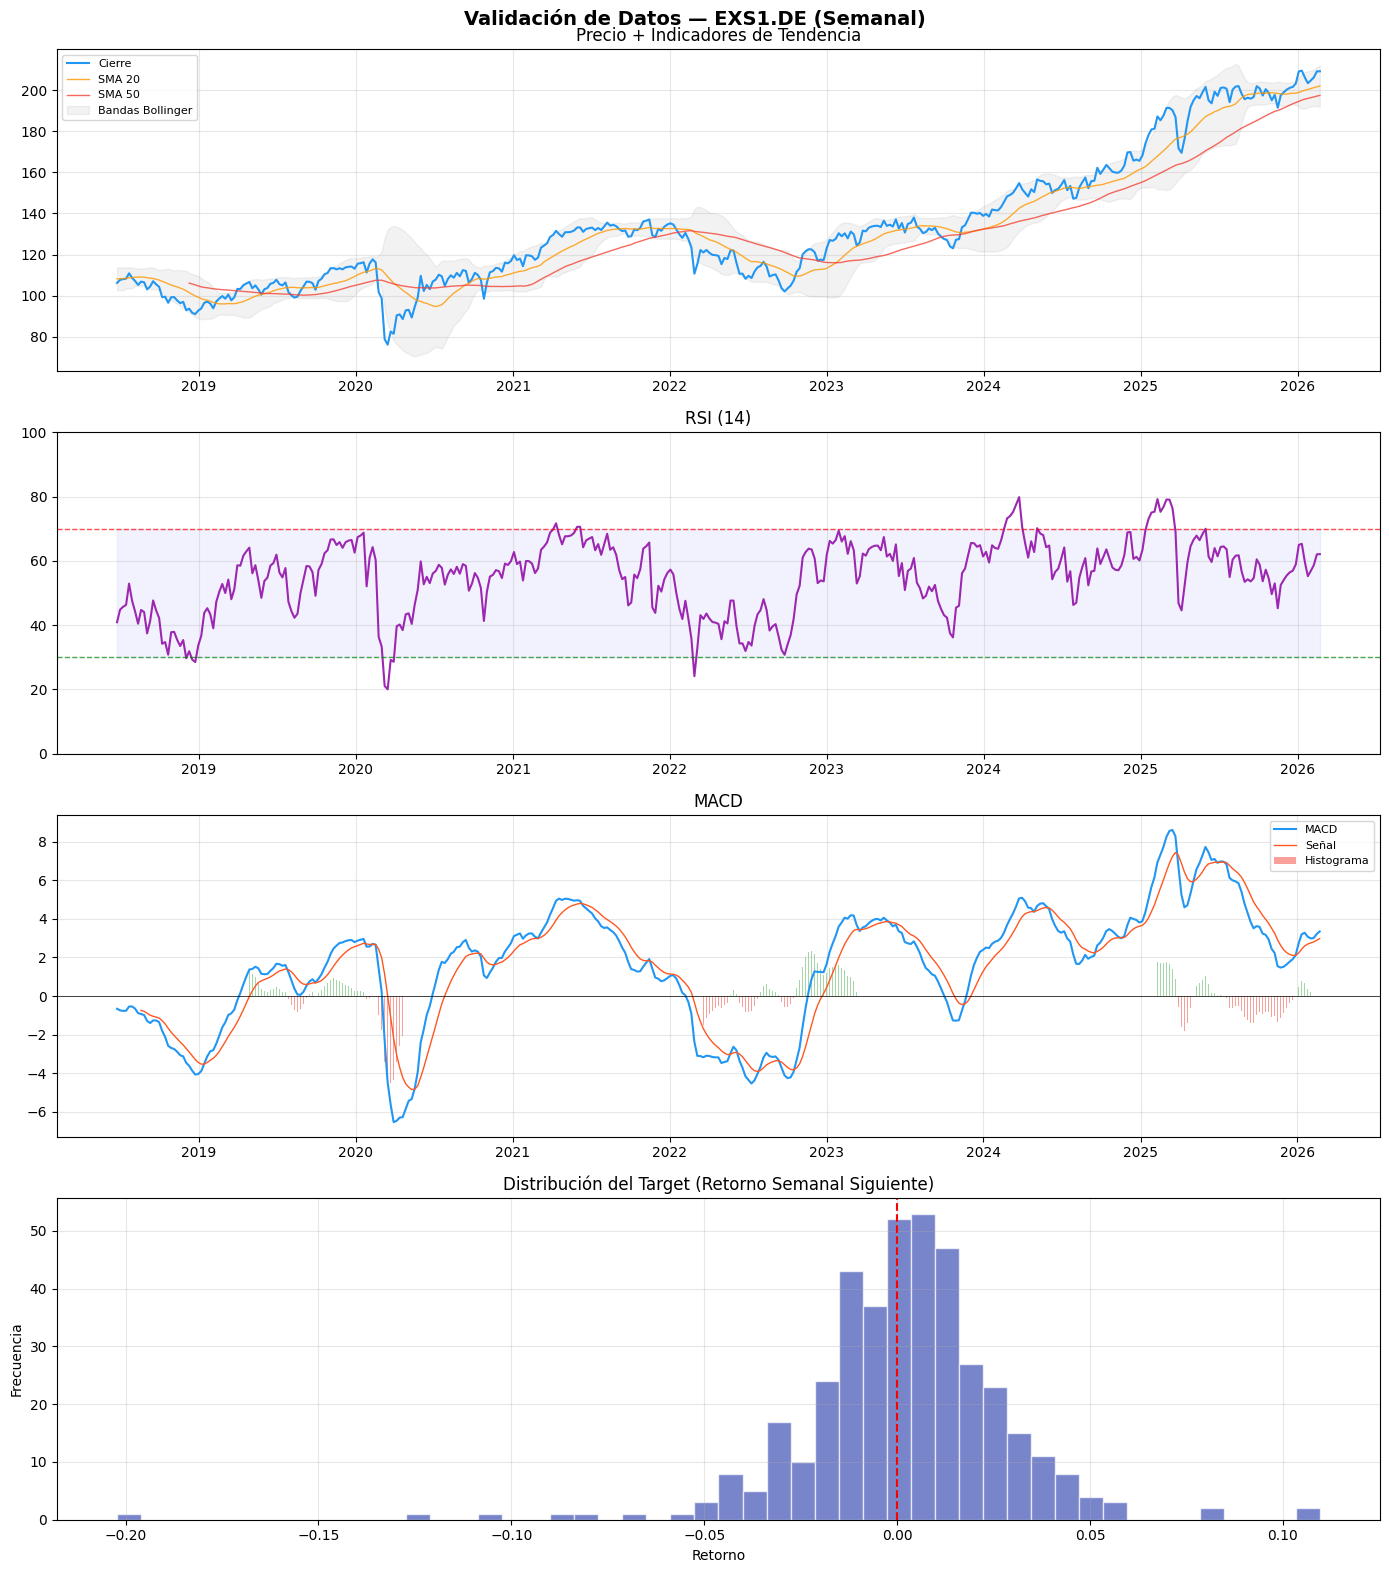

✅ Gráfico guardado en /content/data/validation_plot.png


In [12]:
# Celda 7 — Gráficos de validación (confirmar que los datos son correctos)

fig, axes = plt.subplots(4, 1, figsize=(14, 16))
fig.suptitle(f"Validación de Datos — {CONFIG['PRIMARY_TICKER']} (Semanal)",
             fontsize=14, fontweight="bold")

# 1. Precio de cierre + Medias móviles
ax1 = axes[0]
ax1.plot(df_train.index, df_train["close"], label="Cierre", color="#2196F3", linewidth=1.5)
ax1.plot(df_train.index, df_train["sma_20"], label="SMA 20", color="#FF9800", linewidth=1, alpha=0.8)
ax1.plot(df_train.index, df_train["sma_50"], label="SMA 50", color="#F44336", linewidth=1, alpha=0.8)
ax1.fill_between(df_train.index, df_train["bb_lower"], df_train["bb_upper"],
                 alpha=0.1, color="gray", label="Bandas Bollinger")
ax1.set_title("Precio + Indicadores de Tendencia")
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3)

# 2. RSI
ax2 = axes[1]
ax2.plot(df_train.index, df_train["rsi"], color="#9C27B0", linewidth=1.5)
ax2.axhline(70, color="red", linestyle="--", alpha=0.7, linewidth=1)
ax2.axhline(30, color="green", linestyle="--", alpha=0.7, linewidth=1)
ax2.fill_between(df_train.index, 30, 70, alpha=0.05, color="blue")
ax2.set_title("RSI (14)")
ax2.set_ylim(0, 100)
ax2.grid(True, alpha=0.3)

# 3. MACD
ax3 = axes[2]
ax3.plot(df_train.index, df_train["macd"], label="MACD", color="#2196F3", linewidth=1.5)
ax3.plot(df_train.index, df_train["macd_signal"], label="Señal", color="#FF5722", linewidth=1)
ax3.bar(df_train.index, df_train["macd_diff"],
        color=["#4CAF50" if x > 0 else "#F44336" for x in df_train["macd_diff"]],
        alpha=0.5, label="Histograma")
ax3.axhline(0, color="black", linewidth=0.5)
ax3.set_title("MACD")
ax3.legend(fontsize=8)
ax3.grid(True, alpha=0.3)

# 4. Distribución del target
ax4 = axes[3]
df_train["target_return_next_week"].hist(bins=50, ax=ax4, color="#3F51B5", alpha=0.7, edgecolor="white")
ax4.axvline(0, color="red", linestyle="--", linewidth=1.5)
ax4.set_title("Distribución del Target (Retorno Semanal Siguiente)")
ax4.set_xlabel("Retorno")
ax4.set_ylabel("Frecuencia")
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{CONFIG['DATA_DIR']}/validation_plot.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Gráfico guardado en /content/data/validation_plot.png")